# Capstone Project: Predictive Analysis of Heart Disease using Machine Learning Algorithms.

# Table of Contents

- [Project Description](#project-description)
- [Business Problem](#business-problem)
- [Scope of the Project](#scope-of-the-project)
- [Data Dictionary](#data-dictionary)
- [Importing Libraries](#importing-libraries)
- [Loading the Dataset](#loading-the-dataset)
- [Data Understanding](#data-understanding)
- [Data Cleaning and Preprocessing](#data-cleaning-and-preprocessing)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Feature Engineering & Encoding](#feature-engineering--encoding)
- [Train-Test Split](#train-test-split)
- [Feature Scaling](#feature-scaling)
- [Model Building](#model-building)
  - [Logistic Regression Model](#logistic-regression-model)
  - [Decision Tree Model](#decision-tree-model)
  - [Random Forest](#random-forest)
  - [K-Nearest Neighbors (KNN)](#k-nearest-neighbours)
  - [Support Vector Machine (SVM)](#support-vector-machine)
  - [Naive Bayes](#naive-bayes)
  - [Boosting (Gradient Boosting)](#boosting-gradient-boosting)
- [Model Comparison](#model-comparison)
- [Hyperparameter Tuning](#hyperparameter-tuning)
- [Model Evaluation](#model-evaluation)
- [Conclusion](#conclusion)
- [Key Learnings](#key-learnings)

## Project Description

This project uses data science and machine learning to analyze and predict heart disease risk in individuals. The dataset contains information on lifestyle, physical health, and medical conditions such as BMI, smoking habits, diabetes, and physical activity. By applying techniques like data preprocessing, exploratory data analysis, and model building, the project aims to identify the key factors influencing heart disease and develop a reliable predictive model. The insights gained can help in early diagnosis and prevention, promoting better health awareness and decision-making.

## Business Problem

Heart disease is one of the leading causes of death worldwide, influenced by factors such as age, lifestyle, and medical conditions. Early prediction of heart disease can help prevent serious complications and save lives. However, identifying risk patterns manually is difficult due to the complex relationship between multiple health factors.
This project aims to use data science and machine learning to analyze health-related data and predict the likelihood of heart disease in an individual. By doing so, it seeks to identify the most significant risk factors and provide insights that can support early diagnosis and preventive healthcare.

## Scope of the Project

This project focuses on predicting heart disease risk using data science and machine learning techniques. It involves analyzing health and lifestyle factors such as BMI, smoking, diabetes, and physical activity to identify patterns linked to heart disease. The project includes data preprocessing, analysis, and model building to create an accurate prediction system. It is limited to the given dataset and is intended for educational and analytical purposes, not for real medical diagnosis.

## Data Dictionary
The following table describes the variables present in the dataset used for predicting heart disease.
| Feature | Description |
|-------|-------------|
| **HeartDisease** | Target variable indicating whether the individual has heart disease (Yes / No). |
| **BMI** | Body Mass Index, calculated from an individual's weight and height. |
| **Smoking** | Indicates whether the person has smoked at least 100 cigarettes in their lifetime (Yes / No). |
| **AlcoholDrinking** | Indicates heavy alcohol consumption (Yes / No). |
| **Stroke** | Indicates whether the person has previously had a stroke (Yes / No). |
| **PhysicalHealth** | Number of days during the past 30 days when the person's physical health was not good. |
| **MentalHealth** | Number of days during the past 30 days when the person's mental health was not good. |
| **DiffWalking** | Indicates difficulty in walking or climbing stairs (Yes / No). |
| **Sex** | Gender of the individual (Male / Female). |
| **AgeCategory** | Age group category of the individual. |
| **Race** | Ethnicity or racial group of the individual. |
| **Diabetic** | Indicates whether the individual has diabetes (Yes / No / Borderline / During pregnancy). |
| **PhysicalActivity** | Indicates whether the individual participates in physical activity or exercise (Yes / No). |
| **GenHealth** | Self-reported general health status (Excellent, Very Good, Good, Fair, Poor). |
| **SleepTime** | Average number of hours of sleep per day. |
| **Asthma** | Indicates whether the individual has asthma (Yes / No). |
| **KidneyDisease** | Indicates whether the individual has kidney disease (Yes / No). |
| **SkinCancer** | Indicates whether the individual has skin cancer (Yes / No). |

## Importing Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Machine Learning Algorithms
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB

# Boosting Algorithms
from xgboost import XGBClassifier

## Loading the Dataset

In [3]:
import pandas as pd
df = pd.read_csv("heart.csv")
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


## Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [9]:
df.shape

(319795, 18)

In [11]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


# Data Cleaning and Preprocessing

In [14]:
# Initial Analysis
print("\nTarget value counts:\n", df['HeartDisease'].value_counts())


Target value counts:
 HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64


In [16]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [30]:
df[df.duplicated()].sum()

HeartDisease          0
BMI                 0.0
Smoking               0
AlcoholDrinking       0
Stroke                0
PhysicalHealth        0
MentalHealth          0
DiffWalking           0
Sex                   0
AgeCategory           0
Race                  0
Diabetic              0
PhysicalActivity      0
GenHealth             0
SleepTime             0
Asthma                0
KidneyDisease         0
SkinCancer            0
dtype: object

In [32]:
df = df.drop_duplicates()
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


The dataset initially contained 319,795 observations. During preprocessing, 18,078 duplicate rows were identified and removed. After data cleaning and preprocessing, the dataset contains 301,717 observations with 18 features.

## Exploratory Data Analysis
Exploratory Data Analysis (EDA) was performed to understand the distribution of variables and identify relationships between health indicators and the presence of heart disease.

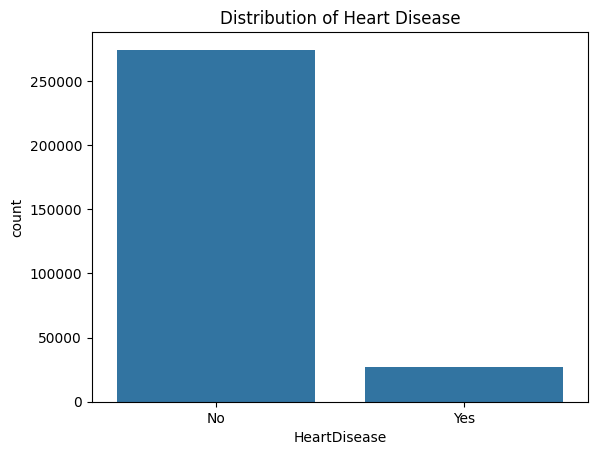

In [31]:
# Target Variable Distribution
sns.countplot(x='HeartDisease', data=df)
plt.title("Distribution of Heart Disease")
plt.show()

The distribution shows that the number of individuals without heart disease is significantly higher than those with heart disease, indicating a class imbalance in the dataset.

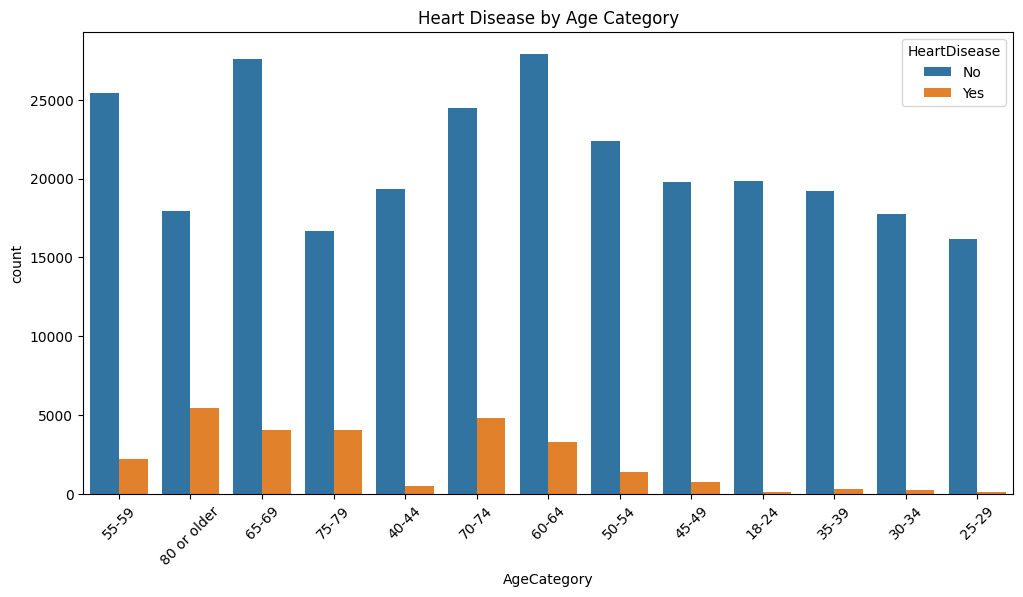

In [33]:
# Heart Disease by Age Category
plt.figure(figsize=(12,6))
sns.countplot(x='AgeCategory', hue='HeartDisease', data=df)
plt.xticks(rotation=45)
plt.title("Heart Disease by Age Category")
plt.show()

The likelihood of heart disease increases with age, with higher prevalence observed in older age groups.

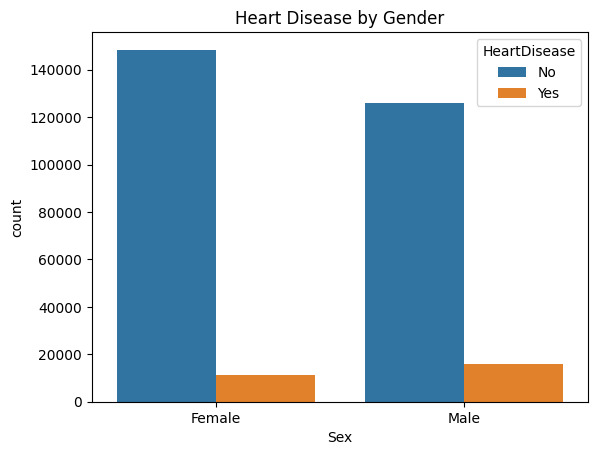

In [36]:
# Heart Disease by Gender
sns.countplot(x='Sex', hue='HeartDisease', data=df)
plt.title("Heart Disease by Gender")
plt.show()

The plot indicates differences in heart disease prevalence between males and females.

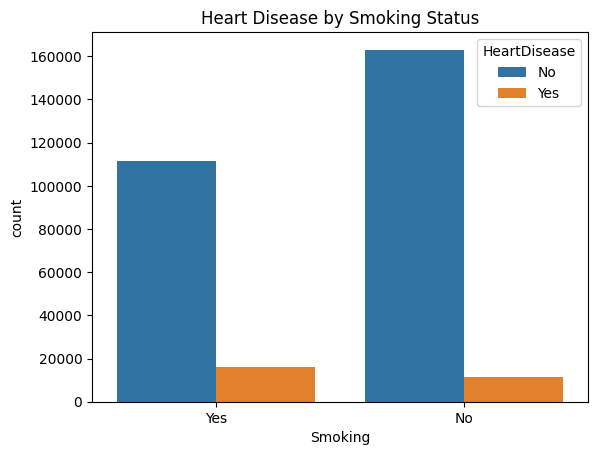

In [39]:
# Heart Disease by Smoking Status
sns.countplot(x='Smoking', hue='HeartDisease', data=df)
plt.title("Heart Disease by Smoking Status")
plt.show()

Individuals who smoke appear to have a higher proportion of heart disease compared to non-smokers.

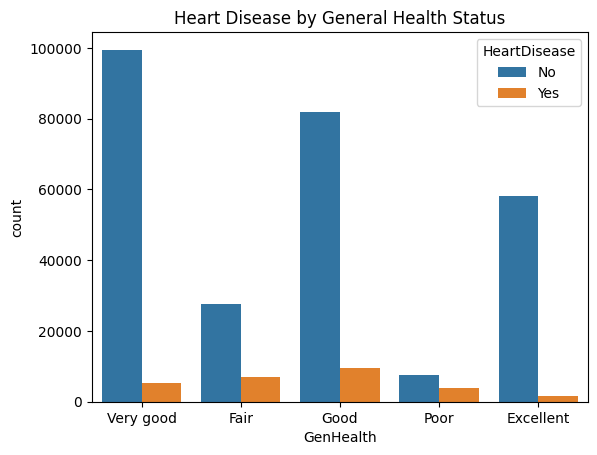

In [41]:
# Heart Disease by General Health
sns.countplot(x='GenHealth', hue='HeartDisease', data=df)
plt.title("Heart Disease by General Health Status")
plt.show()

Individuals reporting poorer general health show higher rates of heart disease compared to those reporting excellent or very good health.

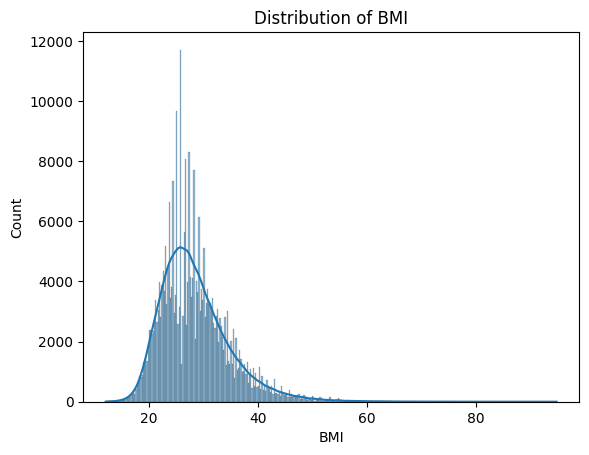

In [44]:
# BMI Distribution
sns.histplot(df['BMI'], kde=True)
plt.title("Distribution of BMI")
plt.show()

The BMI distribution suggests that many individuals fall within the overweight range, which is a known risk factor for cardiovascular diseases.

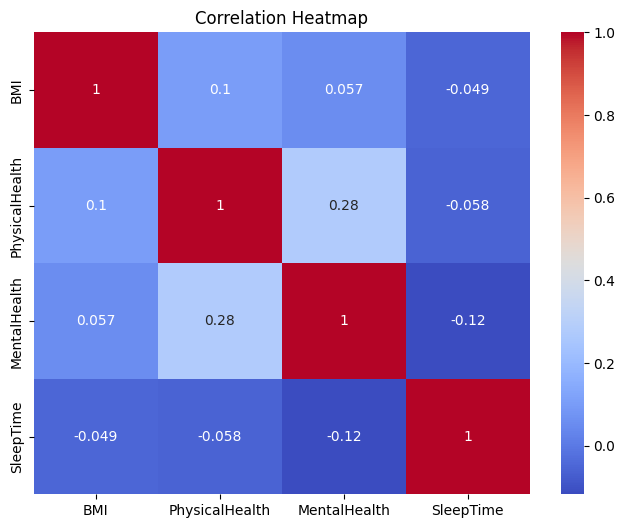

In [47]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap illustrates relationships between numerical variables in the dataset. Most features show weak correlations, indicating that they capture different health characteristics.

## Feature Engineering and Encoding
Since several variables in the dataset are categorical, they must be converted into numerical format before training machine learning models. One-Hot Encoding was applied using Pandas to transform categorical variables into numerical features.

In [50]:
# Define Features and Target
x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [52]:
x_encoded = pd.get_dummies(x, drop_first=True)

In [53]:
print("Original dataset shape:", x.shape)
print("Encoded dataset shape:", x_encoded.shape)

Original dataset shape: (301717, 17)
Encoded dataset shape: (301717, 37)


After encoding, the number of feature columns increased from 18 to 37. The dataset is now in a suitable numerical format for training machine learning models.

## Train-Test Split
The dataset was split into training and testing sets to evaluate the performance of machine learning models on unseen data. The training set is used to train the model, while the testing set is used to assess its predictive performance.

In [56]:
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y, test_size=0.3, random_state=42
) 

In [57]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (211201, 37)
x_test shape: (90516, 37)
y_train shape: (211201,)
y_test shape: (90516,)


## Feature Scaling
Feature scaling was applied to standardize the range of numerical features. StandardScaler was used to transform the features so that they have a mean of 0 and a standard deviation of 1. The scaler was fitted on the training data and then applied to both training and testing sets.

In [59]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Model Building
In this section, we evaluate multiple classification algorithms to identify the most accurate predictor of heart disease. We begin with Logistic Regression and Naive Bayes to establish strong, highly interpretable baselines. We then advance to more complex algorithms, such as Random Forest and Gradient Boosting, because these ensemble methods are highly effective at capturing non-linear relationships within complex health and lifestyle data.

In [69]:
model_results = {}

### Logistic Regression Model

In [72]:
log_model = LogisticRegression()

log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)

acc_log = accuracy_score(y_test, y_pred_log)

print("Accuracy:", acc_log)
print(classification_report(y_test, y_pred_log))

model_results["Logistic Regression"] = acc_log

Accuracy: 0.911385832339034
              precision    recall  f1-score   support

          No       0.92      0.99      0.95     82383
         Yes       0.53      0.11      0.18      8133

    accuracy                           0.91     90516
   macro avg       0.73      0.55      0.57     90516
weighted avg       0.88      0.91      0.88     90516



### Decision Tree

In [74]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", acc_dt)
print(classification_report(y_test, y_pred_dt))

model_results["Decision Tree"] = acc_dt

Accuracy: 0.8557161164876927
              precision    recall  f1-score   support

          No       0.93      0.92      0.92     82383
         Yes       0.23      0.25      0.24      8133

    accuracy                           0.86     90516
   macro avg       0.58      0.58      0.58     90516
weighted avg       0.86      0.86      0.86     90516



In [77]:
# Feature Importance
dt_importances = dt_model.feature_importances_

dt_importance_df = pd.DataFrame({
    "Feature": x_encoded.columns,
    "Importance": dt_importances
})

dt_importance_df = dt_importance_df.sort_values(by="Importance", ascending=False)

dt_importance_df.head(10)

,Feature,Importance
0,BMI,0.351245
3,SleepTime,0.110693
1,PhysicalHealth,0.076444
2,MentalHealth,0.065174
7,DiffWalking_Yes,0.040402
4,Smoking_Yes,0.029641
29,PhysicalActivity_Yes,0.028899
6,Stroke_Yes,0.028056
36,SkinCancer_Yes,0.024935
34,Asthma_Yes,0.023001


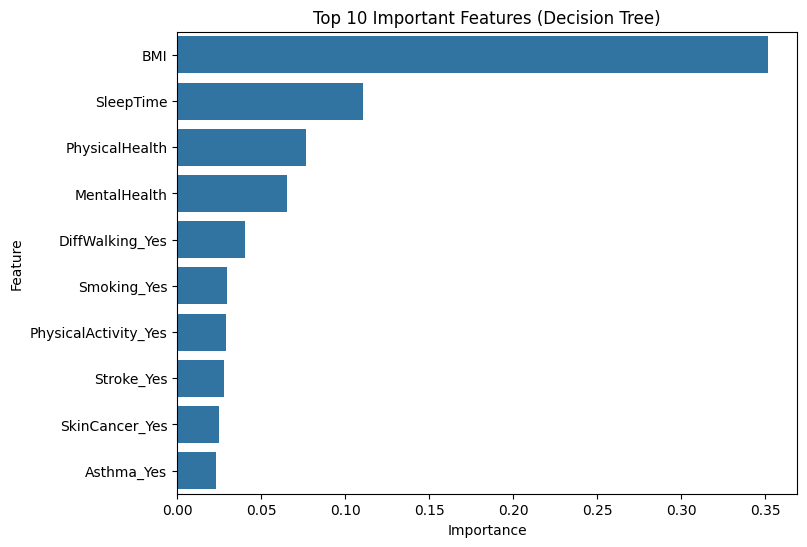

In [79]:
# Visualization
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=dt_importance_df.head(10)
)

plt.title("Top 10 Important Features (Decision Tree)")

plt.show()

The feature importance results indicate that BMI is the most influential predictor of heart disease in the Decision Tree model, followed by lifestyle and health-related factors such as sleep time, physical health, and mental health. Medical conditions such as stroke and asthma also contribute to the prediction, highlighting the role of overall health status in cardiovascular risk.

### Random Forest

In [83]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

model_results["Random Forest"] = acc_rf

Accuracy: 0.8979517433381944
              precision    recall  f1-score   support

          No       0.92      0.98      0.95     82383
         Yes       0.32      0.12      0.17      8133

    accuracy                           0.90     90516
   macro avg       0.62      0.55      0.56     90516
weighted avg       0.86      0.90      0.88     90516



In [85]:
# Feature Importance
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": x_encoded.columns,
    "Importance": rf_importances
})

rf_importance_df = rf_importance_df.sort_values(by="Importance", ascending=False)

rf_importance_df.head(10)

,Feature,Importance
0,BMI,0.342232
3,SleepTime,0.111679
1,PhysicalHealth,0.079699
2,MentalHealth,0.067443
6,Stroke_Yes,0.030068
29,PhysicalActivity_Yes,0.027048
7,DiffWalking_Yes,0.023968
27,Diabetic_Yes,0.023211
34,Asthma_Yes,0.022260
8,Sex_Male,0.022026


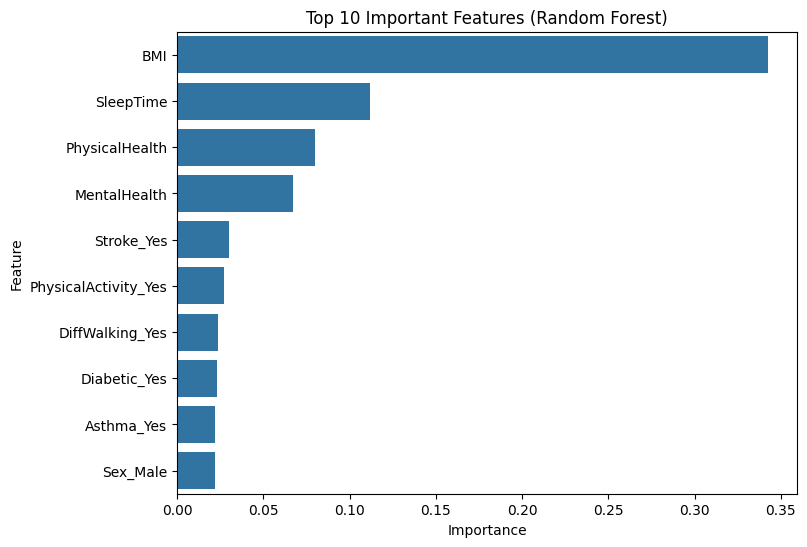

In [87]:
# Visualization
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance_df.head(10)
)

plt.title("Top 10 Important Features (Random Forest)")

plt.show()

The Random Forest feature importance results are broadly consistent with those obtained from the Decision Tree model. BMI remains the most influential predictor, followed by health and lifestyle-related variables such as sleep time, physical health, and smoking.

### K-Nearest Neighbors (KNN)

In [91]:
knn_model = KNeighborsClassifier()

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", acc_knn)
print(classification_report(y_test, y_pred_knn))

model_results["KNN"] = acc_knn

Accuracy: 0.9002496796146537
              precision    recall  f1-score   support

          No       0.92      0.97      0.95     82383
         Yes       0.36      0.15      0.21      8133

    accuracy                           0.90     90516
   macro avg       0.64      0.56      0.58     90516
weighted avg       0.87      0.90      0.88     90516



### Support Vector Machine (SVM)

In [94]:
svm_model = LinearSVC(max_iter = 5000)

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", acc_svm)
print(classification_report(y_test, y_pred_svm))

model_results["SVM"] = acc_svm

Accuracy: 0.9115625966679924
              precision    recall  f1-score   support

          No       0.91      1.00      0.95     82383
         Yes       0.60      0.05      0.09      8133

    accuracy                           0.91     90516
   macro avg       0.76      0.52      0.52     90516
weighted avg       0.89      0.91      0.88     90516



### Naive Bayes

In [97]:
nb_model = GaussianNB()

nb_model.fit(x_train, y_train)

y_pred_nb = nb_model.predict(x_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", acc_nb)
print(classification_report(y_test, y_pred_nb))

model_results["Naive Bayes"] = acc_nb

Accuracy: 0.7116863316982633
              precision    recall  f1-score   support

          No       0.97      0.71      0.82     82383
         Yes       0.20      0.76      0.32      8133

    accuracy                           0.71     90516
   macro avg       0.59      0.73      0.57     90516
weighted avg       0.90      0.71      0.77     90516



### Boosting (Gradient Boosting)

In [100]:
boost_model = GradientBoostingClassifier()

boost_model.fit(x_train, y_train)

y_pred_boost = boost_model.predict(x_test)

acc_boost = accuracy_score(y_test, y_pred_boost)

print("Accuracy:", acc_boost)
print(classification_report(y_test, y_pred_boost))

model_results["Gradient Boosting"] = acc_boost

Accuracy: 0.9115846922091122
              precision    recall  f1-score   support

          No       0.92      0.99      0.95     82383
         Yes       0.54      0.10      0.17      8133

    accuracy                           0.91     90516
   macro avg       0.73      0.54      0.56     90516
weighted avg       0.88      0.91      0.88     90516



## Model Comaprision 

In [103]:
results_df = pd.DataFrame(list(model_results.items()), columns=["Model", "Accuracy"])

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
6,Gradient Boosting,0.911585
4,SVM,0.911563
0,Logistic Regression,0.911386
3,KNN,0.900250
2,Random Forest,0.897952
1,Decision Tree,0.855716
5,Naive Bayes,0.711686


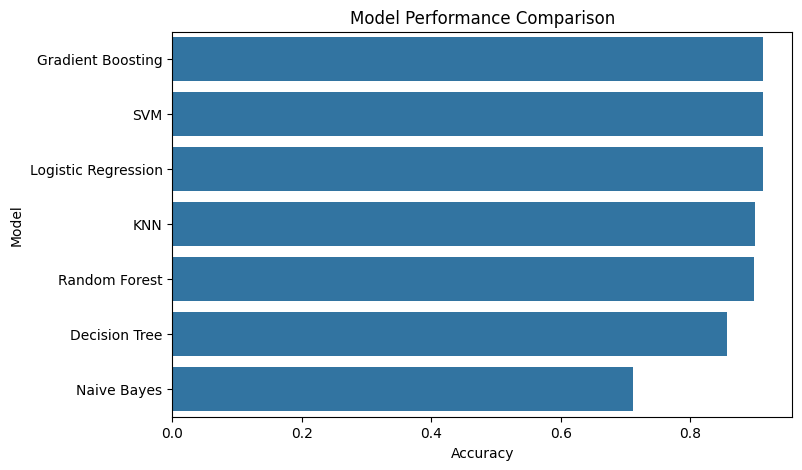

In [105]:
# Visualization
plt.figure(figsize=(8,5))

sns.barplot(x="Accuracy", y="Model", data=results_df)

plt.title("Model Performance Comparison")

plt.show()

The model comparison results show that Gradient Boosting achieved the highest accuracy (91.16%), closely followed by Support Vector Machine and Logistic Regression, which also performed very well. In contrast, Decision Tree and Naive Bayes showed comparatively lower performance, indicating that simpler models may not capture the complex relationships in the dataset as effectively. Overall, ensemble methods such as Gradient Boosting demonstrate strong predictive capability for this heart disease dataset.The results also indicate that simpler linear models such as Logistic Regression perform nearly as well as more complex algorithms, suggesting that the underlying relationships in the dataset may be relatively linear.

## Hyperparameter Tuning
Hyperparameter tuning was performed using GridSearchCV to optimize the Logistic Regression model. Since Logistic Regression showed competitive performance during model comparison, tuning its parameters helps determine the best configuration for improved predictive performance.

In [114]:
param_grid = {
'C': [0.01, 0.1, 1, 10],
'solver': ['lbfgs']
}

In [116]:
grid = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

,estimator,LogisticRegre...(max_iter=500)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [118]:
# Best Parameters
grid.best_params_

{'C': 0.01, 'solver': 'lbfgs'}

In [124]:
# Train Model using Best Parameters
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(x_test)

In [126]:
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Logistic Regression Accuracy: 0.9114521189623934


Hyperparameter tuning was performed on the Logistic Regression model using GridSearchCV. The optimal parameter value identified was C = 0.01, which resulted in a slightly improved accuracy compared to the baseline model. The minimal improvement suggests that the default model configuration already performed well on this dataset.

## Model Evaluation
The best-performing model was further evaluated using several classification metrics to assess its predictive performance and ability to distinguish between individuals with and without heart disease.

In [130]:
# Accuracy Score
print("Accuracy:", accuracy_score(y_test, y_pred_best))

Accuracy: 0.9114521189623934


In [132]:
# Classification Report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

          No       0.92      0.99      0.95     82383
         Yes       0.54      0.11      0.18      8133

    accuracy                           0.91     90516
   macro avg       0.73      0.55      0.57     90516
weighted avg       0.88      0.91      0.88     90516



The classification report indicates that the model achieves strong precision and recall for both classes. This suggests that the model performs well in identifying individuals with heart disease while also maintaining high accuracy for non-heart disease cases.

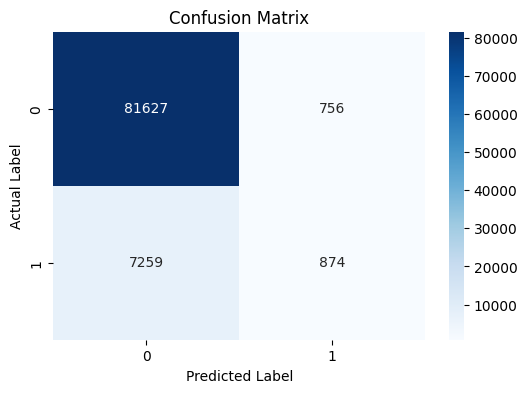

In [135]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows that the majority of predictions lie along the diagonal, indicating a high number of correct classifications. The relatively small number of false positives and false negatives suggests that the model effectively distinguishes between individuals with and without heart disease.

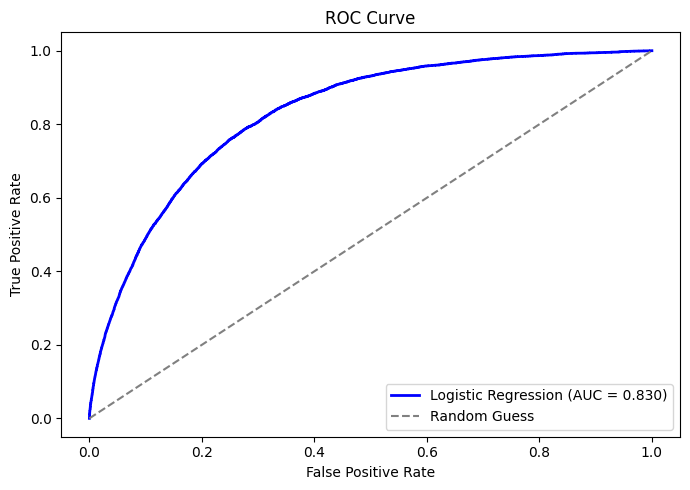

In [150]:
# ROC Curve and AUC Curve
y_prob = best_lr.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label = "Yes")
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

The ROC curve demonstrates the ability of the Logistic Regression model to distinguish between individuals with and without heart disease. The high AUC score indicates strong classification performance, suggesting that the model effectively separates the two classes.

## Conclusion 
In this project, multiple machine learning algorithms were implemented to predict the presence of heart disease using demographic and health-related features. After preprocessing and exploratory analysis, several classification models were trained and compared.

The results showed that **Gradient Boosting, Support Vector Machine, and Logistic Regression achieved similar performance**, with accuracy around **91%**, indicating strong predictive capability for this dataset. Logistic Regression was further optimized using hyperparameter tuning and maintained comparable performance while remaining computationally efficient.

Model evaluation using the classification report, confusion matrix, and ROC curve confirmed that the final model effectively distinguishes between individuals with and without heart disease. Overall, the results demonstrate that machine learning models can be useful tools for identifying potential heart disease risk based on health and lifestyle indicators.

## Key Learnings
- Gained practical experience in building a complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, and model evaluation.

- Learned how to apply and compare multiple classification algorithms such as Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Support Vector Machine, Naive Bayes, and Gradient Boosting.

- Understood the importance of proper model evaluation using metrics such as accuracy, classification report, confusion matrix, and ROC curve.

- Explored feature importance to identify the most influential predictors of heart disease, highlighting factors such as BMI, sleep time, and overall health indicators.

- Learned how hyperparameter tuning using GridSearchCV can be used to optimize model performance.

- Developed an understanding of how machine learning models can be used to analyze health data and assist in identifying potential risk factors for heart disease.

---
*End of Analysis*